In [1]:
# taken from https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

#%matplotlib inline
import argparse
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import torchvision.transforms.v2 as v2transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from PIL import Image
import skimage
from skimage import io, transform

In [ ]:
batch_size = 16
image_size = 324
model_image_size = 128
workers = 2
rootdir = "/Users/ishwar/Downloads"
output_dir = "model_output_090526_128x128_unet"
if not os.path.isdir(output_dir):
    os.mkdir(output_dir)
NUM_LANDMARKS = 5

In [3]:
class SameSizeConv(nn.Module):
    def __init__(self, inchannels, outchannels, p_dropout, num_layers=2):
        super(SameSizeConv, self).__init__()
        self.p_dropout = p_dropout
        
        self.kernelSize = 5
        convs = []

        for _ in range(num_layers):
            convs.append(nn.Conv2d(inchannels, inchannels, self.kernelSize, stride=1, \
                    padding=(self.kernelSize-1)//2, bias=False) )
            convs.append(nn.Conv2d(inchannels, inchannels, self.kernelSize+2, stride=1, \
                    dilation=2, padding=(self.kernelSize+2-1), bias=False) )
            convs.append(nn.BatchNorm2d(inchannels))
            convs.append(nn.LeakyReLU())
            convs.append(nn.Dropout(p=self.p_dropout))

        convs.append(nn.Conv2d(inchannels, inchannels, 1, stride=1, \
                            padding=0, bias=False) )
        convs.append(nn.BatchNorm2d(inchannels))
        convs.append(nn.LeakyReLU())
        convs.append(nn.Dropout(p=self.p_dropout))

        convs.append(nn.Conv2d(inchannels, outchannels, 1, stride=1, \
                            padding=0, bias=False) )
        convs.append(nn.BatchNorm2d(outchannels))
        convs.append(nn.LeakyReLU())
        convs.append(nn.Dropout(p=self.p_dropout))

        self.res_conv = nn.Conv2d(inchannels, outchannels, 1, stride=1, padding=0, bias=False)
        
        self.conv_layers = nn.Sequential(*convs)
    
    def forward(self, x):
        return (self.conv_layers(x) + self.res_conv(x))

In [4]:
class Up(nn.Module):
    def __init__(self, in_channels, out_channels, up):
        super(Up, self).__init__()

        if up == None:
            self.up = nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1, bias=False)
        else:
            self.up = up
        self.res_up = nn.ConvTranspose2d(in_channels, out_channels, 1, stride=1, padding=0, bias=False)
        self.scale_up = nn.Upsample(scale_factor=2, mode='nearest')

        self.kernelSize = 5
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.activation = nn.LeakyReLU()
        self.conv_layers = SameSizeConv(out_channels*2, out_channels, 0)

    def forward(self, x1, x2):
        x = self.activation(self.batch_norm(self.up(x1))) + self.scale_up(self.res_up(x1))
        x = torch.cat([x, x2], dim=1)
        x = self.conv_layers(x)
        return x

In [5]:
#not used
class Up2(nn.Module):
    def __init__(self, in_channels, out_channels, up):
        super(Up2, self).__init__()

        if up == None:
            self.up = nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1, bias=False)
        else:
            self.up = up
        self.res_up = nn.ConvTranspose2d(in_channels, out_channels, 1, stride=1, padding=0, bias=False)
        self.scale_up = nn.Upsample(scale_factor=2, mode='nearest')
        
        self.kernelSize = 5
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.activation = nn.LeakyReLU()
        self.conv_layers = SameSizeConv(out_channels, out_channels, 0)

    def forward(self, x):
        x = self.activation(self.batch_norm(self.up(x))) + self.scale_up(self.res_up(x))
        x = self.conv_layers(x)
        return x

In [6]:
class Down(nn.Module):
    def __init__(self, in_channels, out_channels, down):
        super(Down, self).__init__()

        self.kernelSize = 5
        if down == None:
            self.down = nn.Conv2d(in_channels, out_channels, 4, 2, 1, bias=False)
        else:
            self.down = down
        self.res_down = nn.Conv2d(in_channels, out_channels, 1, stride=1, padding=0, bias=False)
        self.scale_down = nn.MaxPool2d((2, 2), stride=(2, 2))
        
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.activation = nn.LeakyReLU()
        self.conv_layers = SameSizeConv(out_channels, out_channels, 0)

    def forward(self, x):
        x = self.activation(self.batch_norm(self.down(x))) + self.scale_down(self.res_down(x))
        x = self.conv_layers(x)
        return x

In [7]:
class UNet(nn.Module):
    def __init__(self, in_channels, out_channels, supervised_channels, num_skip=6):
        super(UNet, self).__init__()
        
        self.modules = []
        self.kernelSize = 5 # must be odd
        self.p_dropout = 0
        self.num_skip = num_skip
        self.supervised_channels = supervised_channels

        channels = (in_channels, 16)
        self.init_conv = SameSizeConv(channels[0], channels[1], self.p_dropout)
        self.convs0 = SameSizeConv(channels[1], self.supervised_channels + channels[1], self.p_dropout, num_layers=1)
        self.convs0a = SameSizeConv(self.supervised_channels + channels[1], channels[1], self.p_dropout, num_layers=1)
        
        # downsizing
        channels = (16, 16)
        self.downsize1 = Down(channels[0], channels[1], None)
        self.ups1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.convs1 = SameSizeConv(channels[1], self.supervised_channels + channels[1], self.p_dropout, num_layers=1)
        self.convs1a = SameSizeConv(self.supervised_channels + channels[1], channels[1], self.p_dropout, num_layers=1)

        channels = (16, 32)
        self.downsize2 = Down(channels[0], channels[1], None)
        self.ups2 = nn.Upsample(scale_factor=4, mode='nearest')
        self.convs2 = SameSizeConv(channels[1], self.supervised_channels + channels[1], self.p_dropout, num_layers=1)
        self.convs2a = SameSizeConv(self.supervised_channels + channels[1], channels[1], self.p_dropout, num_layers=1)

        channels = (32, 64)
        self.downsize3 = Down(channels[0], channels[1], None)
        self.ups3 = nn.Upsample(scale_factor=8, mode='nearest')
        self.convs3 = SameSizeConv(channels[1], self.supervised_channels + channels[1], self.p_dropout, num_layers=1)
        self.convs3a = SameSizeConv(self.supervised_channels + channels[1], channels[1], self.p_dropout, num_layers=1)

        channels = (64, 128)
        self.downsize4 = Down(channels[0], channels[1], None)

        self.lowest_convs = SameSizeConv(channels[1], channels[1], self.p_dropout, num_layers=2)

        num_skip_temp = self.num_skip

        channels = (128, 64)
        self.upsize4 =  Up(channels[0], channels[1], None) if (num_skip_temp > 0) else Up2(channels[0], channels[1], None)
        num_skip_temp -= 1

        channels = (64, 32)
        self.upsize3 =  Up(channels[0], channels[1], None) if (num_skip_temp > 0) else Up2(channels[0], channels[1], None)
        num_skip_temp -= 1

        channels = (32, 16)
        self.upsize2 =  Up(channels[0], channels[1], None) if (num_skip_temp > 0) else Up2(channels[0], channels[1], None)
        num_skip_temp -= 1

        channels = (16, 16)
        self.upsize1 =  Up(channels[0], channels[1], None) if (num_skip_temp > 0) else Up2(channels[0], channels[1], None)
        num_skip_temp -= 1

        self.final_conv = SameSizeConv(channels[1], out_channels, self.p_dropout)


    def forward(self, input):
        x0 = self.init_conv(input)

        x1 = self.downsize1(x0)
        x1 = F.dropout(x1, p=self.p_dropout)

        x2 = self.downsize2(x1)
        x2 = F.dropout(x2, p=self.p_dropout)

        x3 = self.downsize3(x2)
        x3 = F.dropout(x3, p=self.p_dropout)

        x4 = self.downsize4(x3)
        x4 = F.dropout(x4, p=self.p_dropout)

        f5 = self.lowest_convs(x4)


        num_skip_temp = self.num_skip
        if (num_skip_temp > 0):
            y3 = self.convs3(x3); num_skip_temp -= 1
        if (num_skip_temp > 0):
            y2 = self.convs2(x2); num_skip_temp -= 1
        if (num_skip_temp > 0):
            y1 = self.convs1(x1); num_skip_temp -= 1
        if (num_skip_temp > 0):
            y0 = self.convs0(x0); num_skip_temp -= 1

        #inter3 = self.ups3(y3[:, :self.supervised_channels, :, :])
        #inter2 = self.ups2(y2[:, :self.supervised_channels, :, :])
        #inter1 = self.ups1(y1[:, :self.supervised_channels, :, :])
        #inter0 = y0[:, :self.supervised_channels, :, :]

        num_skip_temp = self.num_skip

        x = self.upsize4(f5, self.convs3a(y3)) if (num_skip_temp > 0) else self.upsize4(f5)
        x = F.dropout(x, p=self.p_dropout)
        num_skip_temp -= 1

        x = self.upsize3(x, self.convs2a(y2)) if (num_skip_temp > 0) else self.upsize4(x)
        x = F.dropout(x, p=self.p_dropout)
        num_skip_temp -= 1

        x = self.upsize2(x, self.convs1a(y1)) if (num_skip_temp > 0) else self.upsize4(x)
        x = F.dropout(x, p=self.p_dropout)
        num_skip_temp -= 1

        x = self.upsize1(x, self.convs0a(y0)) if (num_skip_temp > 0) else self.upsize4(x)
        x = F.dropout(x, p=self.p_dropout)
        num_skip_temp -= 1

        x = self.final_conv(x)

        return [x]#, inter0, inter1, inter2, inter3

In [8]:
class StackedHourglass(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(StackedHourglass, self).__init__()
        self.inchannels = in_channels
        self.outchannels = out_channels
        self.unet1 = UNet(in_channels, out_channels, 0)
        ##self.unet1 = UNet(in_channels, 8+out_channels, out_channels)
        ##self.unet2 = UNet(8+out_channels+in_channels, 8+out_channels, out_channels)
        ##self.unet3 = UNet(8+out_channels+in_channels, out_channels, out_channels)
        #self.unet3 = UNet(8, 8)
        #self.unet4 = UNet(8, out_channels)
    def forward(self, input):
        unet1_ans = self.unet1(input)
        #x = torch.cat([input, unet1_ans[0]], dim=1)
        #unet2_ans = self.unet2(x)
        #x = torch.cat([input, unet2_ans[0]], dim=1)
        #unet3_ans = self.unet3(x)

        endpt_logits = [unet1_ans[0][:, :self.outchannels, :, :]]#, unet2_ans[0][:, :self.outchannels, :, :], unet3_ans[0][:, :self.outchannels, :, :]]
        interior_logits = unet1_ans[1:] # + unet2_ans[1:] + unet3_ans[1:]

        x = unet1_ans[0]
        b = x.shape[0]
        c = self.outchannels
        ##interior = [ F.softmax(heatmap.view(b, c, model_image_size*model_image_size), dim=2).view((b,c,model_image_size,model_image_size))
            ##for heatmap in interior_logits ]
        #x = self.unet2(x)
        #x = self.unet3(x)
        #x = self.unet4(x)
        #x = F.sigmoid(x)
        return endpt_logits##, interior

In [9]:
# Dont USE
weight_spread = 0.05
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Linear') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.05)
        if hasattr(m.bias, 'data'):
            nn.init.constant_(m.bias.data, 0.0)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.05)
        nn.init.normal_(m.bias.data, 0.0, 0.001)
    elif classname.find('Conv2d') != -1:
        # If 'Conv' is found, apply a specific initialization
        #nn.init.kaiming_normal_(m.weight.data, nonlinearity='leaky_relu')
        #nn.init.normal_(m.weight.data, 0.0, 0.01)
        nn.init.normal_(m.weight.data, 0.0, 1.5*(2/(m.weight.shape[0]*m.weight.shape[2]*m.weight.shape[3]))**0.5)
        print(m.weight.shape)
        if hasattr(m.bias, 'data'):
            nn.init.constant_(m.bias.data, 0.0)
    elif classname.find('ConvTranspose2d') != -1:
        # If 'Conv' is found, apply a specific initialization
        #nn.init.normal_(m.weight.data, 0.0, 0.01)
        #nn.init.kaiming_normal_(m.weight.data, nonlinearity='leaky_relu')
        nn.init.normal_(m.weight.data, 0.0, (2/(m.weight.shape[0]*2*2))**0.5)
        print(m.weight.shape)
        if hasattr(m.bias, 'data'):
            nn.init.constant_(m.bias.data, 0.0)
    m = m.to(torch.float32)

clip_value =  5
class WeightConstraint(object):
    def __init__(self):
        pass
    def __call__(self, module):
        # filter the variables to get the ones you want
        if hasattr(module, 'weight'):
            w = module.weight.data
            w = w.clamp(-clip_value, clip_value)
            module.weight.data = w

In [10]:
# Set random seed for reproducibility
manualSeed = 499
#manualSeed = random.randint(1, 10000) # use if you want new results
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)

torch.use_deterministic_algorithms(True) # Needed for reproducible results

Random Seed:  499


In [11]:
#MIN_SIGMA = 1
MAX_SIGMA = 5
def gen_coordinates(coord_array):
    # make 7 coordinates from 5 coordinates
    coord_array_new = torch.zeros((NUM_LANDMARKS, 2))
    coord_array_new[0] = coord_array[0]
    coord_array_new[1] = coord_array[1]
    coord_array_new[2] = (1/2)*((3/5)*coord_array[3] + (2/5)*coord_array[0]) + (1/2)*coord_array[1] # on left wing
    coord_array_new[3] = coord_array[2]
    coord_array_new[4] = (1/2)*((3/5)*coord_array[3] + (2/5)*coord_array[0]) + (1/2)*coord_array[2] # on right wing
    coord_array_new[5] = coord_array[3]
    coord_array_new[6] = coord_array[4]

    coord_array_new[7] = (3/4)*coord_array[0] + (1/4)*coord_array[3]
    coord_array_new[8] = (1/2)*coord_array[0] + (1/2)*coord_array[3]
    coord_array_new[9] = (1/4)*coord_array[0] + (3/4)*coord_array[3]

    return coord_array_new

def coord_to_heatmap(coord_array, image_shape, SIGMA_RATIO, device):
    heatmaps = torch.zeros((NUM_LANDMARKS, image_shape[1], image_shape[2]))
    
    for i in range(NUM_LANDMARKS):
        mu_x, mu_y = coord_array[i][0], coord_array[i][1]   # center (x,y)
        #sigma = sigma_in * model_image_size / image_size
        # calculate average square root distance
        coord_diff = coord_array - torch.stack([coord_array[i],]*NUM_LANDMARKS)
        #print(coord_diff)
        mag = torch.linalg.vector_norm(coord_diff, 2, dim=1)
        mag_remove = torch.cat((mag[:i], mag[i+1:]))
        s = torch.pow(torch.mean(torch.pow(mag_remove + 1e-5, -1)), -1)
        #print(s)
        sigma = MAX_SIGMA #min(SIGMA_RATIO * s + MIN_SIGMA, MAX_SIGMA)

        ys = torch.arange(image_shape[1], device=device, dtype=torch.float32)
        xs = torch.arange(image_shape[2], device=device, dtype=torch.float32)
        yy, xx = torch.meshgrid(ys, xs, indexing='ij')          # HxW each

        img = torch.exp(-0.5 * ((xx - mu_x)**2 + (yy - mu_y)**2) / (sigma**2))
        #img = torch.sqrt((xx - mu_x)**2 + (yy - mu_y)**2)
        # (optional) normalize to peak (1 / 1 + 1e-3)
        #img = torch.round(img / (img.max() + 1e-5))
        heatmaps[i] = (img / (img.sum() + 1e-5))
        #heatmaps[i] = F.softmax(img.view((model_image_size*model_image_size,)), dim=0).view((model_image_size, model_image_size)) * (model_image_size*model_image_size)
    return heatmaps

In [12]:
#SIGMA_RATIO = 0.05
class FramesFromCSV(Dataset):
    def __init__(self, csv_path, images_dir, image_pattern="frame_{frame}.png", transform=None, geo_transform=None, post_geo_transform=None):
        """
        Args:
            csv_path: path to CSV file with header in first row
            images_dir: directory containing frame PNGs
            image_pattern: naming pattern for image files
            transform: optional torchvision transform
        """
        self.images_dir = images_dir
        self.image_pattern = image_pattern
        self.transform = transform
        self.geo_transform = geo_transform
        self.post_geo_transform = post_geo_transform

        # Load CSV into numpy array, skipping header
        self.data = np.loadtxt(csv_path, delimiter=",", skiprows=1)
        # Ensure it's 2D even if only one row
        if self.data.ndim == 1:
            self.data = np.expand_dims(self.data, axis=0)

        self.frame_numbers = self.data[:, 0].astype(int)
        self.points = self.data[:, 1:]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        frame_num = self.frame_numbers[idx]
        coords = self.points[idx]

        # Load image
        img_path = os.path.join(self.images_dir, self.image_pattern.format(frame=frame_num))
        image = Image.open(img_path).convert("RGB")

        # # Reshape coords into N×2 array (x, y)
        coords = coords.reshape(-1, 2)
        coords = torch.tensor(coords, dtype=torch.float32)

        if self.transform:
            image = self.transform(image)
        if self.geo_transform:
            image, coords = self.geo_transform(image, coords)
        if self.post_geo_transform:
            image = self.post_geo_transform(image)

        #augmented_coords = gen_coordinates(coords)
        augmented_coords = coords * model_image_size / image_size
        normalized_image = image*2 - 1

        return {
            "image": normalized_image,
            "points": augmented_coords,
            "heatmaps": coord_to_heatmap(augmented_coords, image.shape, 0.1, "cpu"),
            "frame": frame_num
        }


In [13]:
class RandomAdditiveNoise:
    def __init__(self, p=0.5, mean=0.0, std=0.05):
        self.p = p
        self.mean = mean
        self.std = std

    def __call__(self, x):
        # x: tensor in [0,1], shape (C, H, W)
        if torch.rand(1).item() < self.p:
            noise = torch.randn_like(x) * self.std + self.mean
            x = x + noise
            x = torch.clamp(x, 0.0, 1.0)
        return x

class RandomColorMatrix:
    """
    Applies x -> A x where A is 3x3 with:
      - rank in {1, 2, 3} (each w.p. 1/3)
      - spectral norm <= max_spectral_norm
    """
    def __init__(self, max_spectral_norm=1.5, min_spectral_norm=0.75):
        self.max_spectral_norm = max_spectral_norm
        self.min_spectral_norm = min_spectral_norm

    def _random_orthonormal(self):
        """Generate a random 3x3 orthonormal matrix via QR."""
        M = torch.randn(3, 3)
        Q, _ = torch.linalg.qr(M)  # Q is orthonormal
        return Q

    def __call__(self, x):
        # x: tensor in [0,1], shape (3, H, W)
        c, h, w = x.shape
        assert c == 3, "RandomColorMatrix expects a 3-channel RGB tensor."

        # # Choose rank 1, 2, or 3 with equal probability
        # rank = random.choice([1, 2, 3, 3, 3, 3, 3])

        # # Random orthonormals U, V
        # U = self._random_orthonormal()
        # V = self._random_orthonormal()

        # # Singular values: only 'rank' non-zero, each ≤ max_spectral_norm
        # s = torch.zeros(3)
        # nonzero_s = torch.rand(rank)*(self.max_spectral_norm - self.min_spectral_norm) + self.min_spectral_norm  # [min_spectral_norm, max_spectral_norm)
        # # Sort descending just for sanity (not required)
        # nonzero_s, _ = torch.sort(nonzero_s, descending=True)
        # s[:rank] = nonzero_s
        # S = torch.diag(s)

        # # A = U S V^T; spectral norm = max singular value <= max_spectral_norm
        # A = U @ S @ V.T  # shape (3,3)
        A = torch.eye(c)
        A += torch.randn_like(A)*0.1

        # Apply A to each pixel: x_flat is 3 x (H*W)
        x_flat = x.view(3, -1)
        x_transformed = A @ x_flat
        x_out = x_transformed.view(3, h, w)

        # Clamp back to [0,1]
        x_out = torch.clamp(torch.abs(x_out), 0.0, 1.0)
        return x_out

# random_affine = transforms.RandomAffine(
#     degrees=(-15, 15),           # rotation range in degrees
#     scale=(0.9, 1.1),            # scaling range
#     shear=(-10, 10),              # shear range in degrees
#     translate=(0.5, 0.5)
# )


In [14]:
class ComposeJoint:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, img, pts):
        for t in self.transforms:
            img, pts = t(img, pts)
        return img, pts

# class ResizeWithPoints:
#     def __init__(self, size):
#         """
#         size: (H, W) or int (shorter side)
#         """
#         self.size = size

#     def __call__(self, img, pts):
#         # img.size -> (W, H)
#         old_w, old_h = img.size()

#         img = TF.resize(img, self.size())

#         if isinstance(self.size, tuple):
#             new_h, new_w = self.size()
#         else:
#             # torchvision's int size = shorter side; to keep it simple,
#             # assume you use (H, W) tuple for model_image_size
#             raise ValueError("Use an explicit (H, W) tuple for size")

#         sx = new_w / old_w
#         sy = new_h / old_h

#         scale = torch.tensor([sx, sy], dtype=torch.float32, device=pts.device)
#         pts = pts * scale  # elementwise [x, y] * [sx, sy]
#         return img, pts

class RandomAffineWithPoints:
    """
    Same params as torchvision.transforms.RandomAffine,
    but applied to both image and (N,2) coords.
    """
    def __init__(self, degrees, translate=None, scale=None, shear=None):
        self.degrees = degrees
        self.translate = translate
        self.scale = scale
        self.shear = shear

    def __call__(self, img, pts):
        # img.size is (W, H)
        w, h = img.size()[1:]

        # Sample random params exactly like RandomAffine
        angle, translations, scale, shear = transforms.RandomAffine.get_params(
            self.degrees, self.translate, self.scale, self.shear, (w, h)
        )
        corner_pixel = (img[0, -1, -1].item(), img[1, -1, -1].item(), img[2, -1, -1].item())
        # --- 1) Transform the image ---
        img = TF.affine(
            img,
            angle=angle,
            translate=translations,
            scale=scale,
            shear=shear,
            interpolation = transforms.InterpolationMode.BILINEAR,
            fill=corner_pixel
        )

        center = [w * 0.5, h * 0.5]
        inv_coeffs = TF._get_inverse_affine_matrix(
            center=center,
            angle=angle,
            translate=translations,
            scale=scale,
            shear=shear
        )
        # inv_coeffs = [a, b, c, d, e, f] giving:
        # x_in  = a * x_out + b * y_out + c
        # y_in  = d * x_out + e * y_out + f
        a, b, c, d, e, f = inv_coeffs
        #print(f"{a} {b} {c} {d} {e} {f}")

        M_inv = torch.tensor(
            [[a, b],
             [d, e]],
            dtype=torch.float32,
            device=pts.device,
        )

        M = torch.inverse(M_inv)  # 2×2

        # pts: (N,2) in input image coords
        #ones = torch.ones(pts.shape[0], 1, dtype=torch.float32, device=pts.device)
        #hom = torch.cat([pts, ones], dim=1).T  # 3×N

        #pts_out = (M @ hom).T[:, :2]  # back to (N,2)
        translation = torch.tensor([[c, f]]).repeat(pts.size()[0], 1)
        #print("Translation:\n", translation)
        #print("Points:\n", pts)

        pts_tr = pts - translation

        pts_out = (M @ pts_tr.T).T

        return img, pts_out
    
# geom_transform = ComposeJoint([
#     # ResizeWithPoints((model_image_size, model_image_size)),
#     RandomAffineWithPoints(
#         degrees=(-15, 15),
#         translate=(0.5, 0.5),
#         scale=(0.9, 1.1),
#         shear=(-10, 10),
#     ),
# ])

geom_transform = ComposeJoint([
    # ResizeWithPoints((model_image_size, model_image_size)),
    RandomAffineWithPoints(
        degrees=(-180, 180),
        translate=(0, 0),
        scale=(1.3, 1.5),
        shear=(-7, 7),
    ),
])

In [15]:
dataset = FramesFromCSV(
    csv_path="plane_data/labeled_points_mega_grp.csv",
    images_dir="outp",
    image_pattern="frame_{frame}.png",
    transform=transforms.Compose([
        transforms.Resize(image_size),
        #random_affine,
        transforms.ToTensor(),
        ]),
    geo_transform=geom_transform,
    post_geo_transform=transforms.Compose([RandomColorMatrix(max_spectral_norm=1.5, min_spectral_norm=0.95),
                                           RandomAdditiveNoise(p=0.7, mean=0.0, std=0.025), transforms.Resize(model_image_size)])
)

/Users/ishwar/anaconda3/lib/python3.10/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


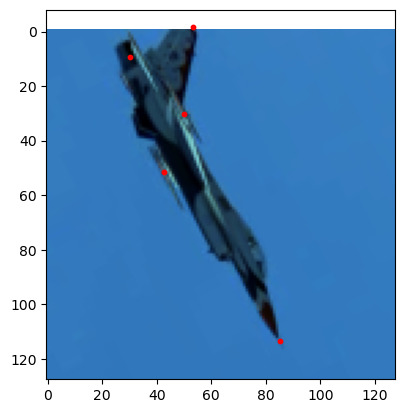

In [16]:
IMG_IDX = 291
IMG = dataset[IMG_IDX]
plt.imshow(torch.permute(IMG['image'], (1, 2, 0))*0.5 + 0.5)
# Unpack points into two lists: xs, ys
xs = [p[0] for p in IMG['points']]
ys = [p[1] for p in IMG['points']]
# Plot points as red circles
plt.scatter(xs, ys, c='red', s=10)  # s = point size

In [17]:
print(torch.min(dataset[IMG_IDX]['image']))
print(torch.max(dataset[IMG_IDX]['image']))
print(dataset[IMG_IDX]['image'].shape)

tensor(-0.9999)
tensor(0.5605)
torch.Size([3, 128, 128])


tensor(0.) tensor(0.0146)
torch.Size([5, 128, 128])


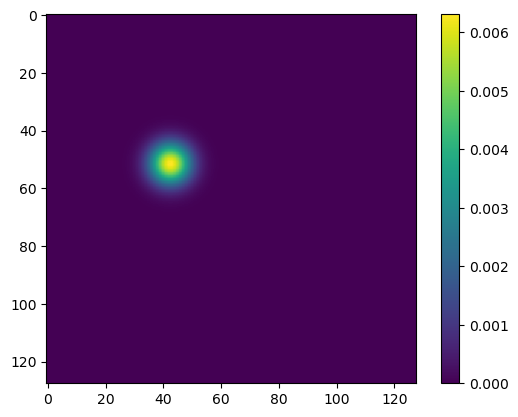

In [18]:
print(torch.min(IMG['heatmaps']), torch.max(IMG['heatmaps']))
print(IMG['heatmaps'].shape)
plt.imshow(IMG['heatmaps'][1])
plt.colorbar()

In [19]:
print(torch.mean(IMG['heatmaps'][1]))

tensor(6.1035e-05)


In [20]:
print(IMG['points'])

tensor([[ 85.3135, 113.4104],
        [ 42.5306,  51.5999],
        [ 50.0329,  30.3347],
        [ 30.2483,   9.2312],
        [ 53.3681,  -1.5863]])


tensor(0.) tensor(0.0146)


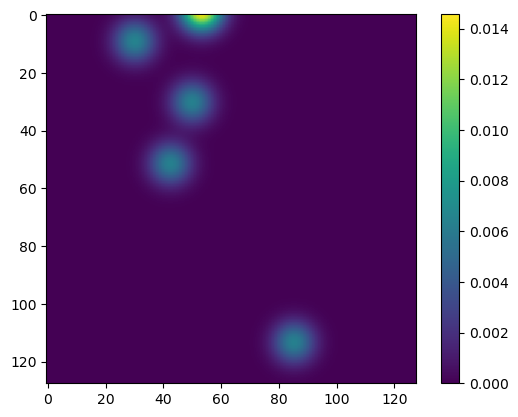

In [21]:
print(torch.min(IMG['heatmaps']), torch.max(IMG['heatmaps']))
plt.imshow(torch.sum(IMG['heatmaps'], axis=0))
plt.colorbar()

In [22]:
total_size = len(dataset)
train_size = int(total_size * 0.8)
val_size = int(total_size * 0.1)
test_size = total_size - train_size - val_size # Ensure all samples are used

In [23]:
seed = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size], generator=seed)

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")


Train size: 732
Validation size: 91
Test size: 92


In [24]:
# loader = DataLoader(dataset, batch_size=batch_size, shuffle=True) # accidentally set shuffle to false all this time
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# for batch in train_loader:
#     print(batch["frame"])
#     print(batch["points"].shape)  # (B, N, 2)
#     break

In [25]:
trial_number = 0

from datetime import datetime
import time

# instantiate generator, discriminator
# borrowed from https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

device = torch.device("mps")
print("device: ", device)

print("Instantiating StackedHourglass")
model = StackedHourglass(3, NUM_LANDMARKS).to(device, dtype=torch.float32)
# model.apply(weights_init)
print(model)

# Setup Adam optimizers for both G and D
optimizer = optim.Adam(model.parameters(), lr=0.0005, betas=(0.5, 0.999))
print("Model optimizer: \n", optimizer)

criterion = nn.MSELoss()

device:  mps
Instantiating StackedHourglass
StackedHourglass(
  (unet1): UNet(
    (init_conv): SameSizeConv(
      (res_conv): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (conv_layers): Sequential(
        (0): Conv2d(3, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
        (1): Conv2d(3, 3, kernel_size=(7, 7), stride=(1, 1), padding=(6, 6), dilation=(2, 2), bias=False)
        (2): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (3): LeakyReLU(negative_slope=0.01)
        (4): Dropout(p=0, inplace=False)
        (5): Conv2d(3, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
        (6): Conv2d(3, 3, kernel_size=(7, 7), stride=(1, 1), padding=(6, 6), dilation=(2, 2), bias=False)
        (7): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (8): LeakyReLU(negative_slope=0.01)
        (9): Dropout(p=0, inplace=False)
        (10): Conv2d(3, 3, kernel_

In [26]:
iters = 0
epoch = 0
num_epochs = 1000
#k=500 # saving images of fixed_noise outputs
last_save = iters
break_flag = False

losses = []

example_idx = 110

In [27]:
def heatmap_softmax(heatmap_list, b, c):
    return [ F.softmax(heatmap.view(b, c, model_image_size*model_image_size), dim=2).view((b,c,model_image_size,model_image_size)) for heatmap in heatmap_list ]

In [28]:
xs = torch.linspace(0.5, model_image_size-0.5, model_image_size, device=device) / model_image_size
ys = torch.linspace(0.5, model_image_size-0.5, model_image_size, device=device) / model_image_size
X, Y = torch.meshgrid(xs, ys, indexing="xy")
pts_template = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=-1)  # (N, 2), N = grid_size^2

f_log = open(f"{output_dir}/training.log", "a")
f_log.write("Initialization scheme initializes Conv2d modules as Kaiming_normal() with own revised implementation (to include kernel size), and Batchnorm multiplier to 1.0, batch size=16, residual is now adding instead of averaging, correction to convtranspose2d init, corrected convtranspose init to multiply by 1.5, scale of error adjusted from (64*64*10^3) to 10^6, included train/validation/test split 80-10-10, changed gaussian variances to be constant\n")

example_indices = [110, 198]

print("Starting Training Loop...")
while (epoch < num_epochs) and (not break_flag):
    # For each batch in the dataloader
    should_break = False
    err_total_loss = 0

    f_log.write(f"Epoch\t{epoch}.\n")
    for i, data in enumerate(train_loader, 0):
    #while False:
        print(f"Epoch\t{epoch}, batch\t{i}.")
        t0 = time.perf_counter()

        data_input = data['image'].to(device, dtype=torch.float32)
        output = data['heatmaps'].to(device, dtype=torch.float32)
        output_coords = data['points'] / model_image_size

        #data_input = data_input.to(device, dtype=torch.float32)

        b = data_input.shape[0]
        c = output.shape[1]

        t1 = time.perf_counter()
        f_log.write(f"Epoch\t{epoch}, batch\t{i}, {b} elements.\n")
        f_log.write(f"\t\tTime for setup: {t1-t0}\n")

        heatmap_logits = model(data_input)
        heatmap_probs = heatmap_softmax(heatmap_logits, b, c)
        predicted_heatmap_stages = heatmap_probs[0]##torch.cat(heatmap_predicted[0], dim=1)
        expected_output_stages = output #output.repeat(1, 3, 1, 1)

        t2 = time.perf_counter()
        f_log.write(f"\t\tTime for forward: {t2-t1}\n")

        model.zero_grad()

        t3 = time.perf_counter()
        f_log.write(f"\t\tTime for zero-grad: {t3-t2}\n")

        #print(expected_output_stages.shape)
        #print(predicted_heatmap_stages.shape)
        err_endpts_sum = criterion(predicted_heatmap_stages, expected_output_stages) * b / batch_size

        ###errs_endpts = []
        ###for j in range(len(heatmap_predicted[0])):
        ###    errs_endpts.append(criterion(heatmap_predicted[0][j], output))
        ###    print(f"Error for intermediate heatmap {j}: {errs_endpts[j].item()}")
        ###losses.append((epoch, i, iters, {f"Stage {j} error endpt": errs_endpts[j].item() for j in range(len(heatmap_predicted[0]))} ) )
        ###err_endpts_sum = (sum(errs_endpts)/len(errs_endpts)) * b / batch_size

        # errs_interior = []
        # for j in range(len(heatmap_predicted[1])):
        #     errs_interior.append(criterion(heatmap_predicted[1][j], output))
        #     print(f"Error for intermediate heatmap {j}: {errs_interior[j].item()}")
        
        # losses.append((epoch, i, iters, {f"Stage {j} error interior": errs_interior[j].item() for j in range(len(heatmap_predicted[1]))} ) )
        # err_interior_sum = (sum(errs_interior)/len(errs_interior)) * b / batch_size

        # err_sum = err_interior_sum*0.5 + err_endpts_sum*0.5
        err_sum = err_endpts_sum * (10**2)**3 # factor to adjust for the scale of the heatmaps
        losses.append( (epoch, i, iters, {f"Stage 0 error": err_sum.item()} ) )

        f_log.write(f"\tTraining loss / batch: {err_sum.item()}\n")
        err_total_loss += err_sum.item()

        t4 = time.perf_counter()
        f_log.write(f"\t\tTime for loss computation: {t4-t3}\n")

        err_sum.backward()

        t5 = time.perf_counter()
        f_log.write(f"\t\tTime for backprop: {t5-t4}\n")

        unet_modules = {"upsize1": model.unet1.upsize1, "upsize2": model.unet1.upsize2, "upsize3": model.unet1.upsize3, "upsize4": model.unet1.upsize4, "downsize1": model.unet1.downsize1, "downsize2": model.unet1.downsize2, "downsize3": model.unet1.downsize3, "downsize4": model.unet1.downsize4, "convs0": model.unet1.convs0, "convs1": model.unet1.convs1, "convs2": model.unet1.convs2, "convs3": model.unet1.convs3}#, "2": model.unet2, "3": model.unet3}
        f_log.write("\tGradient statistics\n")
        for unetnum in unet_modules:
            all_gradients = []
            for name, param in unet_modules[unetnum].named_parameters():
                if param.grad is not None:
                    # Flatten the gradients and convert to numpy
                    all_gradients.append(param.grad.view(-1).cpu().numpy())
            # Concatenate all gradient arrays
            all_gradients = np.abs(np.concatenate(all_gradients))
            f_log.write(f"\tUnet part {unetnum}: {np.min(all_gradients):.2e} to {np.median(all_gradients):.2e} to {np.max(all_gradients):.2e}\n")
            #print(f"\tMedian. {np.median(all_gradients)}. Min {np.min(all_gradients)}. Max {np.max(all_gradients)}")
        f_log.write("\tValue statistics\n")
        for unetnum in unet_modules:
            all_vals = []
            for name, param in unet_modules[unetnum].named_parameters():
                all_vals.append(param.data.view(-1).cpu().numpy())
            # Concatenate all gradient arrays
            all_vals = np.abs(np.concatenate(all_vals))
            f_log.write(f"\tUnet {unetnum}: {np.min(all_vals):.2e} to {np.median(all_vals):.2e} to {np.max(all_vals):.2e}\n")
            #print(f"\tMedian. {np.median(all_vals)}. Min {np.min(all_vals)}. Max {np.max(all_vals)}")

        t6 = time.perf_counter()
        f_log.write(f"\t\tTime for gathering statistics: {t6-t5}\n")
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5) # Clip to a max norm of 1.0

        t7 = time.perf_counter()
        f_log.write(f"\t\tTime for grad clip: {t7-t6}\n")

        optimizer.step()

        t8 = time.perf_counter()
        f_log.write(f"\t\tTime for opt step: {t8-t7}\n")

        iters += 1

        f_log.flush()

    f_log.write(f"Sum of losses over epochs (training): {err_total_loss}\n")
    f_log.write(f"Average of losses over epochs (training): {err_total_loss / train_size}\n")

    losses.append((epoch, -1, iters, {f"Average training loss": err_total_loss / train_size} ) )

    f_log.write(f"Epoch\t{epoch}. Evaluating validation loss\n")
    err_val_loss = 0
    model.eval()
    with torch.no_grad():
        for i, data in enumerate(val_loader, 0):
        #while False:

            t0 = time.perf_counter()

            data_input = data['image'].to(device, dtype=torch.float32)
            output = data['heatmaps'].to(device, dtype=torch.float32)
            output_coords = data['points'] / model_image_size

            b = data_input.shape[0]
            c = output.shape[1]

            t1 = time.perf_counter()
            f_log.write(f"Batch\t{i}, {b} elements.\n")
            f_log.write(f"\t\tTime for setup: {t1-t0}\n")

            heatmap_logits = model(data_input)
            heatmap_probs = heatmap_softmax(heatmap_logits, b, c)
            predicted_heatmap_stages = heatmap_probs[0]##torch.cat(heatmap_predicted[0], dim=1)
            expected_output_stages = output #output.repeat(1, 3, 1, 1)

            t2 = time.perf_counter()
            f_log.write(f"\t\tTime for forward: {t2-t1}\n")

            #print(expected_output_stages.shape)s
            #print(predicted_heatmap_stages.shape)
            err_endpts_sum = criterion(predicted_heatmap_stages, expected_output_stages) * b / batch_size

            ###errs_endpts = []
            ###for j in range(len(heatmap_predicted[0])):
            ###    errs_endpts.append(criterion(heatmap_predicted[0][j], output))
            ###    print(f"Error for intermediate heatmap {j}: {errs_endpts[j].item()}")
            ###losses.append((epoch, i, iters, {f"Stage {j} error endpt": errs_endpts[j].item() for j in range(len(heatmap_predicted[0]))} ) )
            ###err_endpts_sum = (sum(errs_endpts)/len(errs_endpts)) * b / batch_size

            # errs_interior = []
            # for j in range(len(heatmap_predicted[1])):
            #     errs_interior.append(criterion(heatmap_predicted[1][j], output))
            #     print(f"Error for intermediate heatmap {j}: {errs_interior[j].item()}")
            
            # losses.append((epoch, i, iters, {f"Stage {j} error interior": errs_interior[j].item() for j in range(len(heatmap_predicted[1]))} ) )
            # err_interior_sum = (sum(errs_interior)/len(errs_interior)) * b / batch_size

            # err_sum = err_interior_sum*0.5 + err_endpts_sum*0.5
            err_sum = err_endpts_sum * (10**2)**3 # factor to adjust for the scale of the heatmaps
            f_log.write(f"\tValidation loss / batch: {err_sum.item()}\n")
            err_val_loss += err_sum.item()

            t4 = time.perf_counter()
            f_log.write(f"\t\tTime for validation loss computation: {t4-t2}\n")

            f_log.flush()
    
    f_log.write(f"Total validation loss: {err_val_loss}\n")
    f_log.write(f"Average validation loss: {err_val_loss / val_size}\n")

    losses.append((epoch, -1, iters, {f"Average validation loss": err_val_loss / val_size} ) )
    print(f"Loss info length: {len(losses)}")

    model.train()
    
    if should_break:
        break

    if (epoch+1) % 1 == 0:
        for example_idx in example_indices:
            print(f"Saving results for example index {example_idx}")
            f_log.write(f"Saving results for example index {example_idx}\n")
            # output example output from model
            example_point = dataset[example_idx]
            image = torch.permute(example_point['image'], (1, 2, 0))
            plt.imshow(image.numpy())
            plt.savefig(f"{output_dir}/epoch{epoch}_i{example_idx}_in.png")
            plt.clf()

            input_example = example_point['image'].to(device=device, dtype=torch.float32)
            print(torch.min(input_example), torch.max(input_example))
            print(input_example.shape)

            model.eval()
            heatmap_pred = model( torch.stack((input_example,)) )
            heatmap_pred_detach = [y.detach().cpu() for y in heatmap_pred]
            heatmap_probs = heatmap_softmax(heatmap_pred, 1, c)
            heatmap_probs_detach = [y.detach().cpu() for y in heatmap_probs]
            model.train()

            heatmap_actual = example_point['heatmaps']
            print(heatmap_pred_detach[0].shape)
            for i in range(NUM_LANDMARKS):
                plt.imshow(heatmap_actual.numpy()[i])
                plt.colorbar()
                plt.savefig(f"{output_dir}/epoch{epoch}_i{example_idx}_out_{i}_real.png")
                plt.clf()
                for j in range(len(heatmap_pred_detach)):
                    plt.title(f"Heatmap {i} logits")
                    plt.imshow(heatmap_pred_detach[j].numpy()[0][i])
                    plt.colorbar()
                    plt.savefig(f"{output_dir}/epoch{epoch}_i{example_idx}_out_{i}_endpt{j}_logits.png")
                    plt.clf()
                    plt.title(f"Heatmap {i} probabilities")
                    plt.imshow(heatmap_probs_detach[j].numpy()[0][i])
                    plt.colorbar()
                    plt.savefig(f"{output_dir}/epoch{epoch}_i{example_idx}_out_{i}_endpt{j}_probs.png")
                    plt.clf()
                # for j in range(len(heatmap_pred_detach[1])):
                #     plt.imshow(heatmap_pred_detach[1][j].numpy()[0][i])
                #     plt.colorbar()
                #     plt.savefig(f"{output_dir}/epoch{epoch}_out_{i}_inter{j}.png")
                #     plt.clf()

    epoch += 1
    #SIGMA_RATIO = ((SIGMA_RATIO - 0.05) * 0.996) + 0.05
    #f_log.write(f"New SIGMA_RATIO: {SIGMA_RATIO}\n")

f_log.close()

Starting Training Loop...
Epoch	0, batch	0.
Epoch	0, batch	1.
Epoch	0, batch	2.
Epoch	0, batch	3.
Epoch	0, batch	4.
Epoch	0, batch	5.
Epoch	0, batch	6.
Epoch	0, batch	7.
Epoch	0, batch	8.
Epoch	0, batch	9.
Epoch	0, batch	10.
Epoch	0, batch	11.
Epoch	0, batch	12.
Epoch	0, batch	13.
Epoch	0, batch	14.
Epoch	0, batch	15.
Epoch	0, batch	16.
Epoch	0, batch	17.
Epoch	0, batch	18.
Epoch	0, batch	19.
Epoch	0, batch	20.
Epoch	0, batch	21.
Epoch	0, batch	22.
Epoch	0, batch	23.
Epoch	0, batch	24.
Epoch	0, batch	25.
Epoch	0, batch	26.
Epoch	0, batch	27.
Epoch	0, batch	28.
Epoch	0, batch	29.
Epoch	0, batch	30.
Epoch	0, batch	31.
Epoch	0, batch	32.
Epoch	0, batch	33.
Epoch	0, batch	34.
Epoch	0, batch	35.
Epoch	0, batch	36.
Epoch	0, batch	37.
Epoch	0, batch	38.
Epoch	0, batch	39.
Epoch	0, batch	40.
Epoch	0, batch	41.
Epoch	0, batch	42.
Epoch	0, batch	43.
Epoch	0, batch	44.
Epoch	0, batch	45.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Loss info length: 48
Saving results for example index 110
tensor(-1., device='mps:0') tensor(1., device='mps:0')
torch.Size([3, 128, 128])
torch.Size([1, 5, 128, 128])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Saving results for example index 198
tensor(-1., device='mps:0') tensor(1., device='mps:0')
torch.Size([3, 128, 128])
torch.Size([1, 5, 128, 128])
Epoch	1, batch	0.
Epoch	1, batch	1.
Epoch	1, batch	2.
Epoch	1, batch	3.
Epoch	1, batch	4.
Epoch	1, batch	5.
Epoch	1, batch	6.
Epoch	1, batch	7.
Epoch	1, batch	8.
Epoch	1, batch	9.
Epoch	1, batch	10.
Epoch	1, batch	11.
Epoch	1, batch	12.
Epoch	1, batch	13.
Epoch	1, batch	14.
Epoch	1, batch	15.
Epoch	1, batch	16.
Epoch	1, batch	17.
Epoch	1, batch	18.
Epoch	1, batch	19.
Epoch	1, batch	20.
Epoch	1, batch	21.
Epoch	1, batch	22.
Epoch	1, batch	23.
Epoch	1, batch	24.
Epoch	1, batch	25.
Epoch	1, batch	26.
Epoch	1, batch	27.
Epoch	1, batch	28.
Epoch	1, batch	29.
Epoch	1, batch	30.
Epoch	1, batch	31.
Epoch	1, batch	32.
Epoch	1, batch	33.
Epoch	1, batch	34.
Epoch	1, batch	35.
Epoch	1, batch	36.
Epoch	1, batch	37.
Epoch	1, batch	38.
Epoch	1, batch	39.
Epoch	1, batch	40.
Epoch	1, batch	41.
Epoch	1, batch	42.
Epoch	1, batch	43.
Epoch	1, batch	44.
Epoch	1,

...

Loss info length: 4944
Saving results for example index 110
tensor(-0.9985, device='mps:0') tensor(1., device='mps:0')
torch.Size([3, 128, 128])
torch.Size([1, 5, 128, 128])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99981785..1.0].


Saving results for example index 198
tensor(-0.9998, device='mps:0') tensor(1., device='mps:0')
torch.Size([3, 128, 128])
torch.Size([1, 5, 128, 128])
Epoch	103, batch	0.
Epoch	103, batch	1.
Epoch	103, batch	2.
Epoch	103, batch	3.
Epoch	103, batch	4.


KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

In [ ]:
# new_beta2 = 0.99
# for param_group in optimizer.param_groups:
#     # param_group['betas'] is a tuple, so we create a new tuple
#     param_group['betas'] = (param_group['betas'][0], new_beta2)
new_lr = 0.0005
for param_group in optimizer.param_groups:
    param_group['lr'] = new_lr

In [29]:
import math
validation_losses = [x[3]["Average validation loss"]*batch_size for x in losses if ((x[1] == -1) and ("Average validation loss" in x[3]))]
training_losses = [x[3]["Average training loss"]*batch_size for x in losses if ((x[1] == -1) and ("Average training loss" in x[3]))]
epoch_nums = [x[0] for x in losses if ((x[1] == -1) and ("Average training loss" in x[3]))]

batch_losses = [x[3]["Stage 0 error"] for x in losses if ((x[1] != -1) and ("Stage 0 error" in x[3]))]
iter_nums = [x[2] for x in losses if ((x[1] != -1) and ("Stage 0 error" in x[3]))]

In [30]:
print(validation_losses[-5:])
print(training_losses[-5:])
print(epoch_nums[-5:])
print(batch_losses[-5:])
print(iter_nums[-5:])

[0.04008491582922883, 0.03279097853126107, 0.03194706813319699, 0.03144074043074807, 0.03207021394928733]
[0.02543126867035699, 0.027136322538383672, 0.025123381101694264, 0.02675099041862566, 0.025187200739409756]
[98, 99, 100, 101, 102]
[0.023313814774155617, 0.023121336475014687, 0.02840794250369072, 0.02038545534014702, 0.0219108946621418]
[4738, 4739, 4740, 4741, 4742]


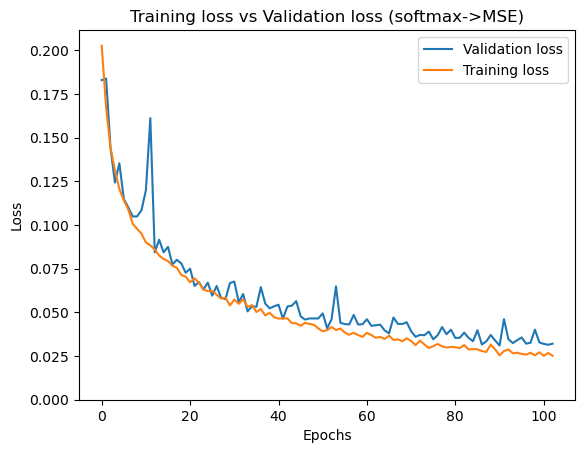

In [31]:
plt.title("Training loss vs Validation loss (softmax->MSE)")
plt.plot(epoch_nums, validation_losses, label="Validation loss")
plt.plot(epoch_nums, training_losses, label="Training loss")
plt.ylim(bottom=0)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

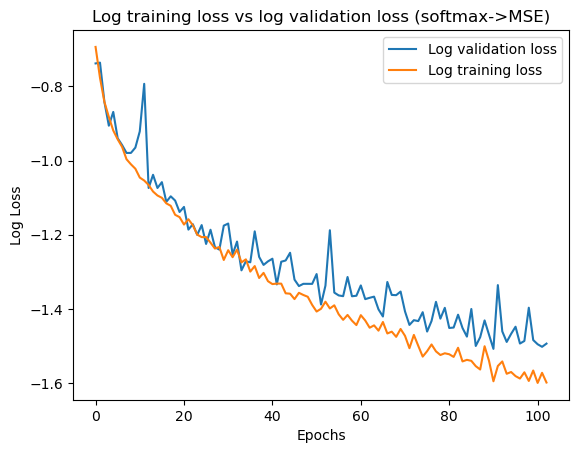

In [32]:
plt.title("Log training loss vs log validation loss (softmax->MSE)")
plt.plot(epoch_nums, [math.log(x, 10) for x in validation_losses], label="Log validation loss")
plt.plot(epoch_nums, [math.log(x, 10) for x in training_losses], label="Log training loss")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

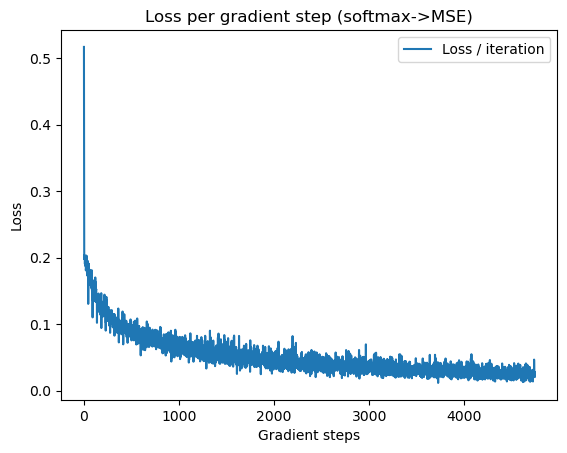

In [33]:
plt.title("Loss per gradient step (softmax->MSE)")
plt.plot(iter_nums, batch_losses, label="Loss / iteration")
plt.xlabel("Gradient steps")
plt.ylabel("Loss")
plt.legend()
plt.show()

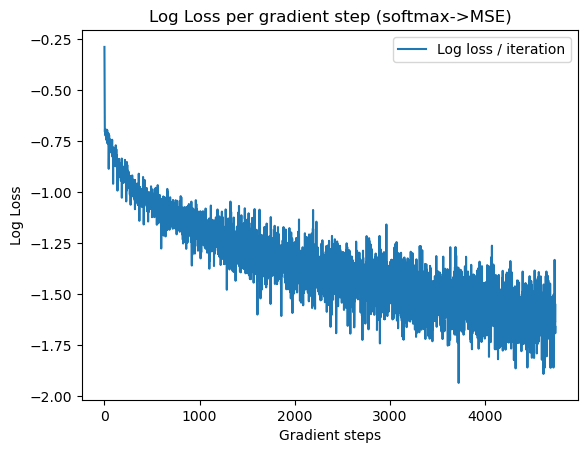

In [34]:
plt.title("Log Loss per gradient step (softmax->MSE)")
plt.plot(iter_nums, [math.log(x, 10) for x in batch_losses], label="Log loss / iteration")
plt.xlabel("Gradient steps")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

In [35]:
torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': losses,
            }, f"{output_dir}/info_model_060626_1000.pt")

In [36]:
model_dict = torch.load(f"{output_dir}/info_model_060626_1000.pt")
model_loaded = StackedHourglass(3, NUM_LANDMARKS)
model_loaded.load_state_dict(model_dict['model_state_dict'])

<All keys matched successfully>

In [37]:
# Assuming 'model' is your defined torch.nn.Module instance
pytorch_total_params = sum(p.numel() for p in model_loaded.parameters())

pytorch_trainable_params = sum(p.numel() for p in model_loaded.parameters() if p.requires_grad)

print(f"Total parameters: {pytorch_total_params}")
print(f"Trainable parameters: {pytorch_trainable_params}")

Total parameters: 10427449
Trainable parameters: 10427449


In [38]:
model_loaded.eval()

StackedHourglass(
  (unet1): UNet(
    (init_conv): SameSizeConv(
      (res_conv): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (conv_layers): Sequential(
        (0): Conv2d(3, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
        (1): Conv2d(3, 3, kernel_size=(7, 7), stride=(1, 1), padding=(6, 6), dilation=(2, 2), bias=False)
        (2): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (3): LeakyReLU(negative_slope=0.01)
        (4): Dropout(p=0, inplace=False)
        (5): Conv2d(3, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
        (6): Conv2d(3, 3, kernel_size=(7, 7), stride=(1, 1), padding=(6, 6), dilation=(2, 2), bias=False)
        (7): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (8): LeakyReLU(negative_slope=0.01)
        (9): Dropout(p=0, inplace=False)
        (10): Conv2d(3, 3, kernel_size=(1, 1), stride=(1, 1), bias=False)
    

In [39]:
DATA_PT = 179
example_point = dataset[DATA_PT]
input_example = example_point['image'].to(dtype=torch.float32)

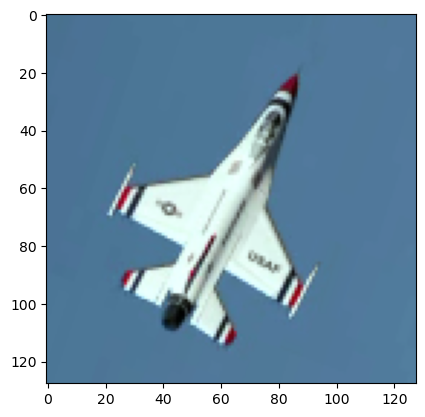

In [40]:
image = torch.permute(example_point['image'], (1, 2, 0))
plt.imshow(image.numpy()*0.5 + 0.5)

tensor(-0.9940) tensor(1.)
torch.Size([3, 128, 128])
torch.Size([5, 128, 128])


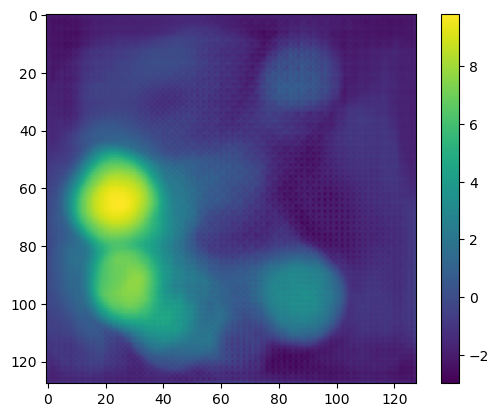

In [41]:
print(torch.min(input_example), torch.max(input_example))
print(input_example.shape)
heatmap_pred = model_loaded( torch.stack((input_example,)) )[0].detach()[0] # take unet outputted by first unet in the stacked hourglass
print(heatmap_pred.shape)
plt.imshow(heatmap_pred.numpy()[1])
plt.colorbar()

In [42]:
# provided by Gemini

# 2. Create a dictionary to store activations
activations = {}

# 3. Define the hook function
def get_activation(name):
    def hook(model, input, output):
        # .detach() removes the tensor from the computation graph
        activations[name] = output.detach()
    return hook

# 4. Register hooks on desired layers
dims = {}
model_loaded.unet1.upsize1.register_forward_hook(get_activation('unet1.upsize1')); dims['unet1.upsize1'] = [1, 16, 128]
model_loaded.unet1.upsize2.register_forward_hook(get_activation('unet1.upsize2')); dims['unet1.upsize2'] = [2, 16, 64]
model_loaded.unet1.upsize3.register_forward_hook(get_activation('unet1.upsize3')); dims['unet1.upsize3'] = [3, 32, 32]
model_loaded.unet1.upsize4.register_forward_hook(get_activation('unet1.upsize4')); dims['unet1.upsize4'] = [4, 64, 16]
model_loaded.unet1.convs0a.register_forward_hook(get_activation('unet1.convs0a')); dims['unet1.convs0a'] = [0, 16, 128]
model_loaded.unet1.convs1a.register_forward_hook(get_activation('unet1.convs1a')); dims['unet1.convs1a'] = [1, 16, 64]
model_loaded.unet1.convs2a.register_forward_hook(get_activation('unet1.convs2a')); dims['unet1.convs2a'] = [2, 32, 32]
model_loaded.unet1.convs3a.register_forward_hook(get_activation('unet1.convs3a')); dims['unet1.convs3a'] = [3, 64, 16]
model_loaded.unet1.lowest_convs.register_forward_hook(get_activation('unet1.lowest_convs')); dims['unet1.lowest_convs'] = [-1, 128, 8]
model_loaded.unet1.final_conv.register_forward_hook(get_activation('unet1.final_conv')); dims['unet1.final_conv'] = [-1, 13, 128]

# 5. Perform a forward pass
#sample_input = torch.randn(1, 3, 32, 32) # Batch size 1, 3 channels, 32x32 image
_ = model_loaded( torch.stack((input_example,)) ) # Run the model

# 6. Access the stored activations
print(f"Shape of conv1 output: {activations['unet1.upsize1'].shape}")

Shape of conv1 output: torch.Size([1, 16, 128, 128])


In [ ]:
for which_layer in dims:
    num_channels = dims[which_layer][1]
    im_dim = dims[which_layer][2]
    # Define the grid dimensions
    columns = 4
    rows = (num_channels+columns-1)//columns

    # 2. Create figure and axes
    # fig is the entire figure, axs is a 2D array of axes (subplots)
    fig, axs = plt.subplots(rows, columns, figsize=(8, 3+rows))

    fig.suptitle(f"{which_layer} features ({im_dim}x{im_dim})", fontsize=16, y=1)

    images = [np.random.rand(10, 10) * i for i in range(1, 5)]
    vmin = torch.min(activations[which_layer]).item()
    vmax = torch.max(activations[which_layer]).item()
    # 2. Create the normalization and mappable
    norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = matplotlib.cm.ScalarMappable(norm=norm, cmap='viridis')

    titles = ["Channel "+str(i) for i in range(num_channels)]
    # 3. Iterate through axes and display images
    # Use .flatten() to turn the 2D array of axes into a 1D array for easy iteration
    for i, ax in enumerate(axs.flatten()):
        if i >= num_channels:
            break
        ax.imshow(activations[which_layer][0][i].numpy())
        ax.set_title(titles[i]) # Set a title for each subplot
        ax.axis('off') # Hide the axes ticks and labels for cleaner image presentation

    # Adjust layout for better spacing
    plt.tight_layout()
    fig.colorbar(sm, ax=axs, orientation='horizontal', label='Shared Scale')
    # Display the figure
    plt.savefig(f"{which_layer}_{DATA_PT}.png")

NameError: name 'columns' is not defined

In [40]:
import frame_manager
import importlib
importlib.reload(frame_manager)

<module 'frame_manager' from '/Users/ishwar/Desktop/Desktop/Aero_ML/frame_manager.py'>

In [44]:
SMOOTH_CONST = 1
# ---------- Main runner ----------
@torch.inference_mode()
def run_video_demo(model, source=0, device=None, window_name="Landmark Demo"):
    """
    source: 0 for webcam, or path to video file.
    model: a loaded torch.nn.Module that outputs heatmaps (B,C,Hh,Wh)
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.eval().to(device)

    cap = cv2.VideoCapture(source)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video source: {source}")

    t_prev = time.time()
    fps_ema = None

    try:
        while True:
            ok, frame = cap.read()
            if not ok: break

            # Keep a copy for drawing at native res
            out_frame = frame.copy()

            # Preprocess & infer
            tin, orig_wh = preprocess_frame(frame, device)
            # Optional: mixed precision for speed on GPU
            with torch.cuda.amp.autocast(enabled=(device == "cuda")):
                pred = F.softmax(model(tin), dim=1)                 # expect (1, C, Hh, Wh)
            if pred.dim() == 5: pred = pred[0]    # in case model returns (pred, aux)
            if pred.shape[0] == 1: pred = pred    # (1,C,Hh,Wh)
            _, C, Hh, Wh = pred.shape

            # Get coords in model-input space
            xs_in, ys_in = heatmaps_to_coords(pred)      # each (1,C)
            xs_in, ys_in = xs_in[0], ys_in[0]            # (C,)

            # Draw
            draw_points(out_frame, xs_in, ys_in, orig_wh)

            # FPS
            t_now = time.time()
            fps = 1.0 / max(t_now - t_prev, 1e-6)
            fps_ema = fps if fps_ema is None else 0.9*fps_ema + 0.1*fps
            t_prev = t_now
            put_fps(out_frame, fps_ema)

            cv2.imshow(window_name, out_frame)
            key = cv2.waitKey(1) & 0xFF
            if key in (27, ord('q')):  # ESC or q
                break
    finally:
        cap.release()
        cv2.destroyAllWindows()


class LatestFrameGrabber:
    """Continuously grabs frames on a background thread and keeps only the most recent one."""
    def __init__(self, source=0):
        self.cap = cv2.VideoCapture(source)
        if not self.cap.isOpened():
            raise RuntimeError(f"Could not open video source: {source}")
        # Best-effort: keep tiny buffer (works on some backends; harmless otherwise)
        try:
            self.cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)
        except Exception:
            pass
        self.lock = threading.Lock()
        self.frame = None
        self.stopped = False
        self.t = threading.Thread(target=self._update, daemon=True)
        self.t.start()

    def _update(self):
        while not self.stopped:
            ok, f = self.cap.read()
            if not ok:
                self.stopped = True
                break
            with self.lock:
                self.frame = f

    def read(self):
        with self.lock:
            return None if self.frame is None else self.frame.copy()

    def release(self):
        self.stopped = True
        try:
            self.t.join(timeout=1.0)
        except Exception:
            pass
        self.cap.release()

import time, cv2, torch

@torch.inference_mode()
def run_video_demo_fixed_rate(model, source=0, device=None, window_name="Landmark Demo",
                              sample_hz=15.0, show_fps=True):
    """
    Samples the *latest* frame every 1/sample_hz seconds, runs inference on that frame,
    and displays only those results. Drops frames between ticks to avoid latency buildup.
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.eval().to(device)

    grab = LatestFrameGrabber(source)  # from previous code: grabs frames on a thread
    dt = 1.0 / float(max(sample_hz, 1e-6))
    next_t = time.perf_counter()  # monotonic clock

    disp_fps_ema = None
    try:
        while True:
            now = time.perf_counter()
            # sleep until the next scheduled tick (keeps rate steady, avoids drift)
            if now < next_t:
                time.sleep(next_t - now)
                continue
            # schedule the following tick
            next_t += dt

            t0 = time.perf_counter()
            frame = grab.read()
            if frame is None:
                # No new frame yet; skip this tick but keep schedule
                continue

            out_frame = frame.copy()

            # Preprocess & infer on the ticked frame
            tin, orig_wh = preprocess_frame(frame, device)
            with torch.cuda.amp.autocast(enabled=(device == "cuda")):
                tin = tin.to(dtype=torch.float32)
                pred = model(tin)  # (1, C, Hh, Wh)

            xs_in, ys_in = heatmaps_to_coords(pred)   # each (1, C) in model-input coords
            xs_in, ys_in = xs_in[0], ys_in[0]
            draw_points(out_frame, xs_in, ys_in, orig_wh)

            # Display + UI FPS (UI FPS may be ~ sample_hz)
            t1 = time.perf_counter()
            ui_fps = 1.0 / max(t1 - t0, 1e-6)
            disp_fps_ema = ui_fps if disp_fps_ema is None else 0.9*disp_fps_ema + 0.1*ui_fps
            if show_fps:
                put_fps(out_frame, disp_fps_ema)
                cv2.putText(out_frame, f"Sample: {sample_hz:.1f} Hz",
                            (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2, cv2.LINE_AA)

            cv2.imshow(window_name, out_frame)
            key = cv2.waitKey(1) & 0xFF
            if key in (27, ord('q')):
                break

            # If inference was slower than dt, catch the schedule up (drop extra ticks)
            # so next tick isn't delayed by accumulated lag.
            now2 = time.perf_counter()
            while next_t < now2 - 1e-4:
                next_t += dt
    finally:
        grab.release()
        cv2.destroyAllWindows()

import time, cv2, torch

@torch.inference_mode()
def run_video_demo_auto(model, source=0, device=None, window_name="Landmark Demo",
                        sample_hz=15.0, show_fps=True):
    """
    - If source is webcam (fps not available) → run at fixed sample_hz (e.g. 15 Hz).
    - If source is video file (fps available) → throttle playback to the file's FPS.
    """

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.eval().to(device)

    cap = cv2.VideoCapture(source)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video source: {source}")

    # Try to read FPS from file
    fps_file = cap.get(cv2.CAP_PROP_FPS)
    if fps_file is None or fps_file <= 1e-2:  # webcams often report 0
        mode = "webcam"
        dt = 1.0 / float(max(sample_hz, 1e-6))   # fixed rate
        print(f"[INFO] Webcam mode: target {sample_hz} Hz")
    else:
        mode = "file"
        dt = 1.0 / fps_file
        print(f"[INFO] Video file mode: target {fps_file:.2f} FPS")

    next_t = time.perf_counter()
    disp_fps_ema = None

    prev_xs_in_smooth, prev_ys_in_smooth = None, None

    prev_mask = [None] * 4
    prev_pred = None
    i = 0

    tau = 0.1

    try:
        while True:
            ok, frame = cap.read()
            if not ok:
                break
            out_frame = frame.copy()

            i += 1
            if i % 5 != 0:
                continue

            # preprocess
            tin, orig_wh = frame_manager.preprocess_frame(frame, device)

            # inference
            ##pred = F.softmax(model(tin), dim=1).detach()  # (1, C, H, W)
            model_output = model((tin*2 - 1))
            pred_logits = [x.detach() / tau for x in model_output]  # (1, C, H, W)
            pred_probs = heatmap_softmax(pred_logits, 1, NUM_LANDMARKS)
            pred_probs = [x.cpu() for x in pred_probs]
            """
            out_frame_2 = out_frame.copy().astype(np.float32)
            if (prev_pred is None):
                pred_smooth = pred
            else:
                pred_smooth = 0.3*pred + 0.7*prev_pred
            prev_pred = pred_smooth
            pred_round = torch.round(pred_smooth)
            for i in range(0, 3): 
                colored_heatmap = torch.permute(torch.tensor([255, 255, 255]) - torch.tensor(frame_manager.COLORS[i]).repeat(128, 128, 1), (2, 0, 1)) * pred_round[0][i].repeat(3, 1, 1).view(1, 3, 128, 128)
                # print(out_frame_2.shape)
                # print(colored_heatmap.shape)
                new_img = F.interpolate(colored_heatmap, size=(324, 324), mode='bilinear').to(torch.uint8)
                new_img_2 = (torch.ones(new_img.shape)*255 - new_img*0.5)/255
                # print(new_img.shape)
                mask = torch.permute(new_img_2, (0, 2, 3, 1)).view(324, 324, 3).numpy()
                
                out_frame_2 = out_frame_2 * mask

            out_frame_2 = out_frame_2.astype(np.uint8)
            """

            xs_in, ys_in = frame_manager.heatmaps_to_coords(pred_probs[0])
            #xs_in, ys_in = xs_in[0], ys_in[0]
            if prev_xs_in_smooth is None:
                xs_in_smooth, ys_in_smooth = xs_in, ys_in
            else:
                xs_in_smooth, ys_in_smooth = xs_in*SMOOTH_CONST + prev_xs_in_smooth*(1-SMOOTH_CONST), ys_in*SMOOTH_CONST + prev_ys_in_smooth*(1-SMOOTH_CONST)
            frame_manager.draw_points(out_frame, xs_in_smooth, ys_in_smooth, orig_wh)
            prev_xs_in_smooth, prev_ys_in_smooth = xs_in_smooth, ys_in_smooth

            # UI FPS
            now = time.perf_counter()
            ui_fps = 1.0 / max(now - next_t + dt, 1e-6)
            disp_fps_ema = ui_fps if disp_fps_ema is None else 0.9*disp_fps_ema + 0.1*ui_fps
            if show_fps:
                frame_manager.put_fps(out_frame, disp_fps_ema)

            ## cv2.imshow(window_name, out_frame_2)
            cv2.imshow(window_name, out_frame)
            key = cv2.waitKey(1) & 0xFF
            if key in (27, ord('q')):
                break

            # pacing
            if mode == "webcam":
                # sleep until next scheduled tickq
                now = time.perf_counter()
                if now < next_t:
                    time.sleep(next_t - now)
                next_t += dt
            else:  # file
                wait_ms = int(max(1, dt * 1000))
                if cv2.waitKey(wait_ms) & 0xFF in (27, ord('q')):
                    break

    finally:
        cap.release()
        cv2.destroyAllWindows()


In [45]:
# or a file:
run_video_demo_auto(model_loaded, device=device, source="ignore/plane_2.mov", sample_hz=60.0)

[INFO] Video file mode: target 59.85 FPS


In [ ]:
DATA_PT = 10
example_point = dataset[DATA_PT]
#example_point = dataset[115]
image = torch.permute(example_point['image'], (1, 2, 0))
plt.imshow(image.numpy()*0.5 + 0.5)

In [ ]:
input_example = example_point['image'].to(dtype=torch.float32)
print(torch.min(input_example), torch.max(input_example))
print(input_example.shape)
heatmap_pred = model( torch.stack((input_example,)) )[0][2].detach()
print(heatmap_pred.shape)

In [ ]:
plt.imshow(heatmap_pred[0].numpy()[1])
plt.colorbar()